# Part 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import final

## a) Delta Hedging

### i. Simulation

In [2]:
def delta_hedge_sim(freq, steps_per_year, seed=42):
    """
    Simulates total PnL of a delta hedged short put option position to expiry, with 2000 GBM paths.
    """
    S0 = 100
    K = 105
    r = 0.04
    q = 0
    sigma = 0.3
    T = 2
    mu = 0.085

    m = 2000 # 2k paths

    dt = 1 / steps_per_year
    n = int(steps_per_year * T) # total steps

    S, _, _ = final.geometric_brownian_motion(m, n, S0, mu, sigma, dt=dt, seed=seed)
    i_grid = np.linspace(0, T, n+1)
    time_left = T - i_grid

    V = np.zeros(S.shape)
    D = np.zeros(S.shape)

    # t=0 to n-1
    V[:, :-1] = final.bs_price(S[:, :-1], K, time_left[:-1], r, sigma, q, is_call=False)
    D[:, :-1] = final.bs_delta(S[:, :-1], K, time_left[:-1], r, sigma, q, is_call=False)

    # t=n (expiry)
    is_itm = S[:, -1] < K
    V[:, -1] = np.where(is_itm, K - S[:, -1], 0) # if itm then value is intrinsic val
    D[:, -1] = np.where(is_itm, -1, 0) # approaches -1 as itm and 0 as otm

    final_position = D[:, -1] * S[:, -1] - V[:, -1]
    initial_portfolio_fv = (D[:, 0] * S[:, 0] - V[:, 0]) * np.exp(r * T) # T is just n * h

    delta_diff = np.diff(D, axis=1)
    S_rebal = S[:, 1:]

    interest_factors = np.exp(r * (T - i_grid[1:])) # use everything but initial to calc interest
    rebalancing_costs = delta_diff * S_rebal * interest_factors
    total_rebal_costs_fv = np.sum(rebalancing_costs, axis=1)

    pnl = final_position - (initial_portfolio_fv + total_rebal_costs_fv)
    return np.mean(pnl), np.std(pnl)

In [3]:
frequencies = {
    'Bi-monthly': 6,
    'Monthly': 12,
    'Bi-weekly': 26,
    'Weekly': 52,
    'Daily': 252,
    '2x Day': 504
}
results_delta = {
    'Freq': [],
    'Mean': [],
    'Std': []
}

In [4]:
for name, freq in frequencies.items():
    mu_pnl, std_pnl = delta_hedge_sim(name, freq, seed=42)
    results_delta['Freq'].append(name)
    results_delta['Mean'].append(mu_pnl)
    results_delta['Std'].append(std_pnl)
results_delta = pd.DataFrame(results_delta)
results_delta

,Freq,Mean,Std
0,Bi-monthly,-0.125913,4.421747
1,Monthly,-0.135830,3.175832
2,Bi-weekly,-0.116969,2.113649
3,Weekly,-0.032949,1.487527
4,Daily,-0.006638,0.701201
5,2x Day,0.003803,0.492925


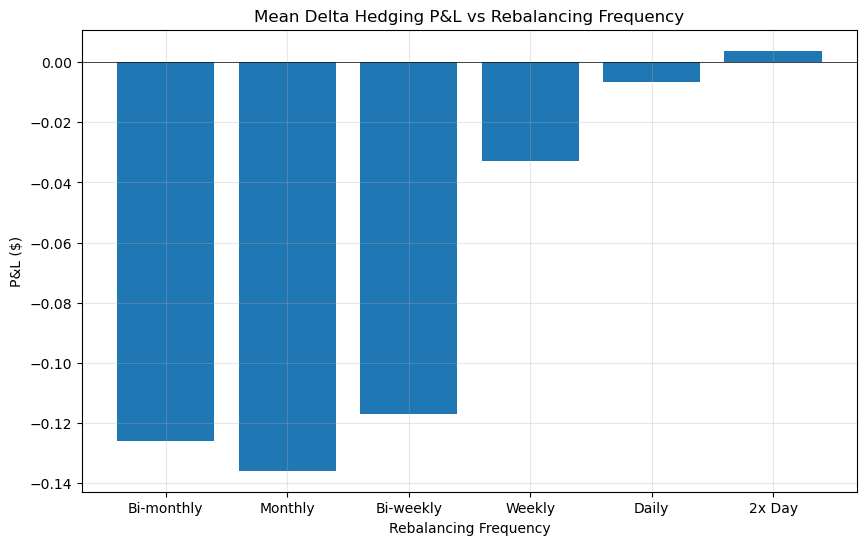

In [5]:
plt.figure(figsize=(10, 6))
plt.bar(results_delta['Freq'], results_delta['Mean'])
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Mean Delta Hedging P&L vs Rebalancing Frequency')
plt.xlabel('Rebalancing Frequency')
plt.ylabel('P&L ($)')
plt.grid(True, alpha=0.3)
plt.show()

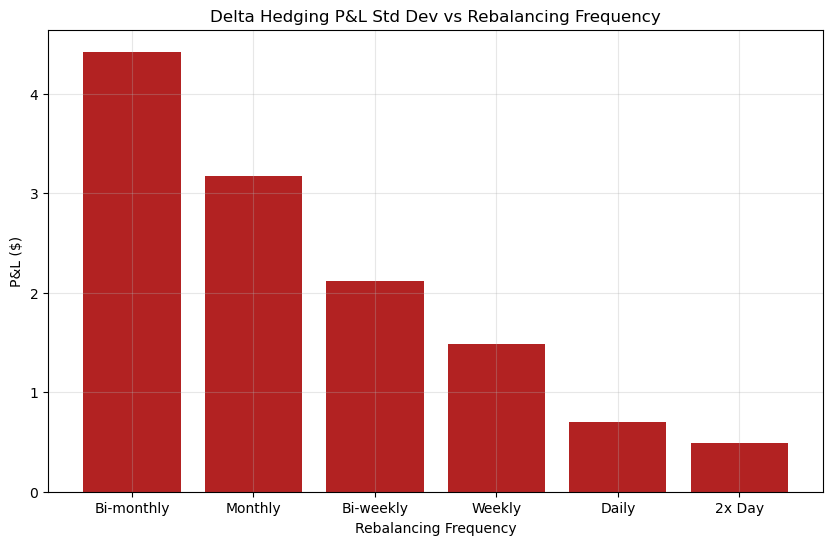

In [6]:
plt.figure(figsize=(10, 6))
plt.bar(results_delta['Freq'], results_delta['Std'], color='firebrick')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Delta Hedging P&L Std Dev vs Rebalancing Frequency')
plt.xlabel('Rebalancing Frequency')
plt.ylabel('P&L ($)')
plt.grid(True, alpha=0.3)
plt.show()

### ii. Questions

* When the option expires in the money, $\Delta_n \to -1$; it approaches 0 when it expires out of the money. When the option expires in the money, $V_n$ is equal to the payoff, which is $K-S_n$ where $S_n$ is the price of the underlying at maturity and $K$ is the strike price; $V_n=0$ when it expires out of the money.
* The graph makes sense. The BSM framework states that as hedging frequency increases, the process becomes more deterministic and the error is reduced. In the plots, the hedging error decreases as the hedging frequency increases and the mean PnL is also around 0 for all of the frequencies.
* Since we shorted a put, we have positive $\Delta$ exposure. To neutralize this, we take a short position in $\lvert \Delta \rvert$ shares of stock (negative $\Delta$).

## b) Gamma Hedging

### i. Simulation

In [7]:
def gamma_hedge_sim(freq, steps_per_year, seed=42):
    """
    Simulates total PnL of a short put option that is both delta-hedged and gamma-hedged. 
    """
    S0 = 100
    K_put = 105
    K_call = 115
    r = 0.04
    q = 0
    sigma = 0.3
    T = 2
    mu = 0.085

    m = 2000 # 2k paths

    dt = 1 / steps_per_year
    n = int(steps_per_year * T) # total steps

    S, _, _ = final.geometric_brownian_motion(m, n, S0, mu, sigma, dt=dt, seed=seed)

    i_grid = np.linspace(0, T, n+1)
    time_left = T - i_grid

    D_put = np.zeros(S.shape)
    G_put = np.zeros(S.shape)
    V_put = np.zeros(S.shape)

    D_call = np.zeros(S.shape)
    G_call = np.zeros(S.shape)
    V_call = np.zeros(S.shape)

    # also calculate gamma now
    D_put[:, :-1] = final.bs_delta(S[:, :-1], K_put, time_left[:-1], r, sigma, q, is_call=False)
    G_put[:, :-1] = final.bs_gamma(S[:, :-1], K_put, time_left[:-1], r, sigma, q)
    V_put[:, :-1] = final.bs_price(S[:, :-1], K_put, time_left[:-1], r, sigma, q, is_call=False)

    # calculate same stuff for the call option
    D_call[:, :-1] = final.bs_delta(S[:, :-1], K_call, time_left[:-1], r, sigma, q, is_call=True)
    G_call[:, :-1] = final.bs_gamma(S[:, :-1], K_call, time_left[:-1], r, sigma, q)
    V_call[:, :-1] = final.bs_price(S[:, :-1], K_call, time_left[:-1], r, sigma, q, is_call=True)

    is_itm_put = S[:, -1] < K_put
    V_put[:, -1] = np.where(is_itm_put, K_put - S[:, -1], 0)
    D_put[:, -1] = np.where(is_itm_put, -1.0, 0.0)
    G_put[:, -1] = 0.0 # No gamma at expiry

    # call at expiry
    is_itm_call = S[:, -1] > K_call
    V_call[:, -1] = np.where(is_itm_call, S[:, -1] - K_call, 0)
    D_call[:, -1] = np.where(is_itm_call, 1.0, 0.0)
    G_call[:, -1] = 0.0 

    omega_call = np.zeros(S.shape)
    # calculate weights
    omega_call[:, :-1] = G_put[:, :-1] / (G_call[:, :-1] + 1e-10) # prevent zero div issues by adding epsilon and slicing to last
    omega_stock = D_put - (omega_call * D_call) # calc stock weights

    final_position = (omega_stock[:, -1] * S[:, -1]) + (omega_call[:, -1] * V_call[:, -1]) - V_put[:, -1]
    
    # sold put, bought call, bought stock
    initial_portfolio_val = (omega_stock[:, 0] * S[:, 0]) + (omega_call[:, 0] * V_call[:, 0]) - V_put[:, 0]
    initial_portfolio_fv = initial_portfolio_val * np.exp(r * T)

    # getting changes in weights to calc rebalance
    dw_stock = np.diff(omega_stock, axis=1)
    dw_call = np.diff(omega_call, axis=1)

    # Rebalance after first period (0)
    S_rebal = S[:, 1:]
    V_call_rebal = V_call[:, 1:]
    
    # similar logic to delta hedging, except with call as well
    interest_factors = np.exp(r * (T - i_grid[1:]))
    rebalancing_costs = (dw_stock * S_rebal + dw_call * V_call_rebal) * interest_factors
    total_rebal_costs_fv = np.sum(rebalancing_costs, axis=1)

    pnl = final_position - (initial_portfolio_fv + total_rebal_costs_fv)
    return np.mean(pnl), np.std(pnl)

In [8]:
results_gamma = {
    'Freq': [],
    'Mean': [],
    'Std': []
}
for name, freq in frequencies.items():
    mu_pnl, std_pnl = gamma_hedge_sim(name, freq, seed=42)
    results_gamma['Freq'].append(name)
    results_gamma['Mean'].append(mu_pnl)
    results_gamma['Std'].append(std_pnl)
results_gamma = pd.DataFrame(results_gamma)
results_gamma

,Freq,Mean,Std
0,Bi-monthly,0.015047,1.483646
1,Monthly,0.009773,1.059254
2,Bi-weekly,-0.032872,0.821194
3,Weekly,-0.030926,0.470480
4,Daily,-0.000249,0.189756
5,2x Day,0.000260,0.112576


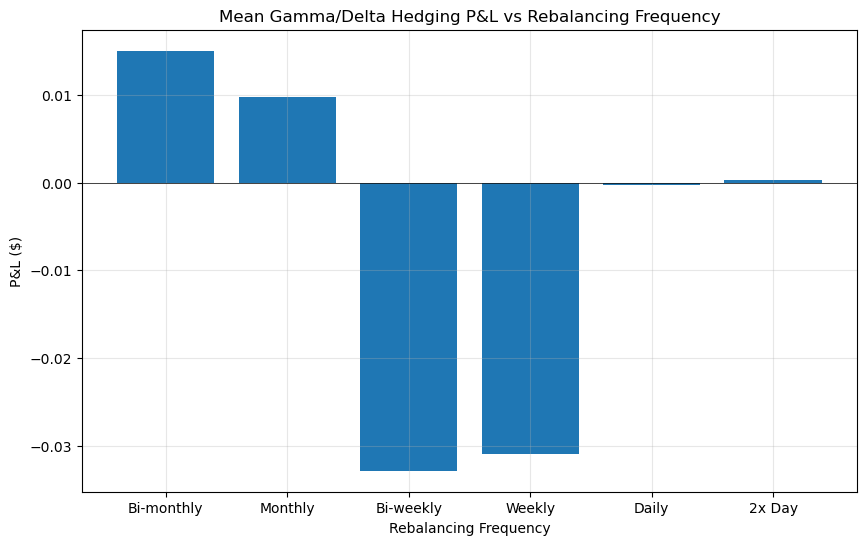

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(results_gamma['Freq'], results_gamma['Mean'])
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Mean Gamma/Delta Hedging P&L vs Rebalancing Frequency')
plt.xlabel('Rebalancing Frequency')
plt.ylabel('P&L ($)')
plt.grid(True, alpha=0.3)
plt.show()

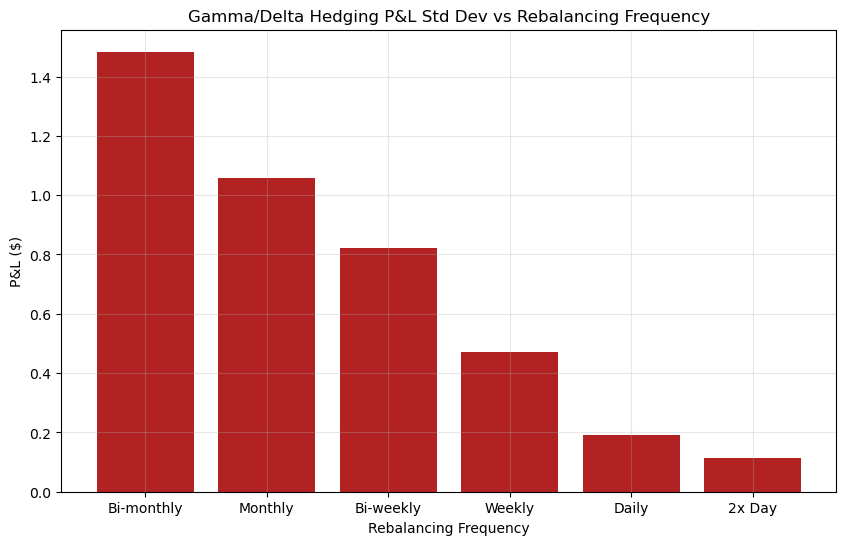

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(results_gamma['Freq'], results_gamma['Std'], color='firebrick')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Gamma/Delta Hedging P&L Std Dev vs Rebalancing Frequency')
plt.xlabel('Rebalancing Frequency')
plt.ylabel('P&L ($)')
plt.grid(True, alpha=0.3)
plt.show()

### ii. Questions

* From the perspective of the portfolio, the short position has negative $\Gamma$, as we lose money if the stock moves wildly in either direction (since we are delta-hedged). However, the put itself has positive $\Gamma$. Thus, $\omega_H=\frac{\Gamma_V}{\Gamma_H}$, which will be positive (both numerator and denominator are positive). This cancels out the negative $\Gamma$ exposure we got from the short put.
* We know $\omega_S=\Delta_V - \omega_H\Delta_H$. The first term is negative, since the $\Delta$ of a put is negative (value increases as the stock goes down). As I showed in the last question, $\omega_H$ is positive, and so is $\Delta_H$ (option value increases as underlying price increases). This increases the short position in the stock. Intuitively, we have positive delta from our short put, create negative delta to hedge by shorting the stock, buy calls to hedge gamma (gamma is negative, need to create positive gamma), which leads to more positive delta. To hedge this, we increase our short position in stock.
* It decreases it. For each frequency, the hedging error is lower for gamma and delta-hedging. This is because we are able to hedge "second-order risk", making the portfolio more stable against large price moves. This is what we expect from the theory (second-order effects in Taylor expansion).